In [1]:
import numpy as np 
import Physical_Const as phys
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq,curve_fit
from scipy.integrate import ode, odeint


import WD.neutrinos as nunu
import WD.CarbonFusion as eCC
import WD.EoS_ionee as EOS
import WD.ion_electron as ionee
import WD.ions as ion
import WD.electron_electron as ee
import WD.Cv_star as cv
import WD.opacity as op

import MR_Relation.WD_HT as WD


/home/laura/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
#----Constants------

hbar     = phys.hbar
c        = phys.c
G        = phys.G
SigmaSB  = phys.sigmaSB
me_mev   = phys.me
e        = phys.e
e_erg    = phys.e_erg
mevtoerg = phys.mevtoerg
mu       = phys.mu
kappaB   = phys.kappa
Msun     = phys.Msun
Rsun     = phys.Rsun
Lsun     = phys.Lsun

h        = hbar * ( 2.0 * np.pi )
c2       = c*c
me       = me_mev * mevtoerg / c2
arad     = 4.0 * SigmaSB / c
Tr       = me * c2 / kappaB
pi05     = np.sqrt( np.pi )
RBohr    = hbar**2 / ( me * e_erg )
avo      = 1.0 / mu

yr       = 364*24*60*60

In [3]:
#  ---Dimensions---
MA       = 2.0
Cgrav    = G * Msun / c2
Jdim     = G / c**3
mpl      = np.sqrt(hbar * c / G) # planck mass
Rdim     = ( mpl / me )**2.0 * hbar / (mpl * c)
Mdim     = Rdim / Cgrav

Sigma02  = np.power( c / Rdim,2.0) / G

Sigma    = np.power(me,4.0)*np.power(c,3.0)/(8.0*np.power(np.pi,2.0)*np.power(hbar,3.0))
SigmaP   = c2 * Sigma

Bdim     =  np.sqrt(G )  * Rdim / c2  

#Tdim     = ( MA * mu *c2) / kappaB
Tdim     = np.power( c**3 / ( 4.0 * np.pi * G * SigmaSB * Rdim**2) ,1.0/4.0)
Ldim     =  4.0 * np.pi * Rdim**2 * SigmaSB * Tdim**4

Jadim    = 1e50
JJdim    = Jadim * Jdim  / Rdim**2

rhobeta  = np.log10(3.9e10)

In [4]:
#---Algoritm first derivativa----------
def factorD(x,x0,x1,x2,x3):
    den = 3.0 * x * x - 2.0 * x * ( x1 + x2 + x3 ) + x1 * x2 + x2 * x3 + x1 * x3
    num = ( x0 - x1 ) * ( x0 - x2 ) * ( x0 - x3 )
    return den/num

def fit_derivative(xpoints,ypoints):
    NN    = len(xpoints)
    dd    = np.zeros(NN)
    dd[0] =   ( ypoints[1] - ypoints[0] ) / ( xpoints[1] - xpoints[0] )  
    dd[1]=    ( ypoints[3] - ypoints[0] ) / ( xpoints[3] - xpoints[0] ) 
   
    for i in range(2,NN-2):
        xi = xpoints[i]
        x0 = xpoints[i-2]
        x1 = xpoints[i-1]
        x2 = xpoints[i+1]
        x3 = xpoints[i+2]
        
        dd[i] = ypoints[i-2]*factorD(xi,x0,x1,x2,x3) + ypoints[i-1]*factorD(xi,x1,x0,x2,x3) + ypoints[i+1]*factorD(xi,x2,x0,x1,x3) + ypoints[i+2]*factorD(xi,x3,x0,x1,x2)
        
    dd[NN-2] =   ( ypoints[-2] - ypoints[-3] ) / ( xpoints[-2] - xpoints[-3] )  
    dd[NN-1] =   ( ypoints[-1] - ypoints[-2] ) / ( xpoints[-1] - xpoints[-2] )  
    
    return dd

In [5]:
# RMFT EOS
rhoEoS, xeEoS, PEoS, PsatEoS, chip_EoS = np.loadtxt("./C12_with_elec_energy.dat",usecols=(0,1,2,3,4),unpack=True)

# --- Degenerate electronic Pressure -----
def Pch_EoS(x):

    x2  = x*x
    
    if x > 2e-3:
        ww  = np.sqrt( 1.0 + x2) + x 
        pWD = x * np.sqrt( 1.0 + x2 ) * ( 2.0 * x2/3.0  - 1.0 ) +  np.log( ww ) 
    else:
        x3 = x2*x
        x5 = x3*x2
        x7 = x5*x2
        x9 = x7*x2
        x11 = x9*x2
        pWD = -2.77556e-17*x3 + 0.533333*x5 - 0.190476*x7 + 0.111111*x9 - 0.0757576*x11
    
    #pWD = SigmaP*(x*np.sqrt(1.0+np.power(x,2.0))*(2.0*np.power(x,2.0)/3.0-1.0)+np.log(np.sqrt(1.0+np.power(x,2.0))+x))
    return SigmaP * pWD

def func(x, b):
    return ( np.power(10.0,rhof) / Sigma02 ) * np.power(x,b)/np.power(xemax,b)

# --- Magnetic field -----
def Magnetic(rho, Bs, B0):
    rho0    = 1e9 /  Sigma02
    x       = rho / rho0
    eta     = 0.8
    gamma   = 0.9
    
    Bfield  = Bs + B0*( 1.0 - np.exp( -eta * x**gamma ) )
    DBfield =  B0 *  np.exp( -eta * x**gamma )  * ( eta * gamma * x**(gamma - 1.0) ) / rho0
    
    return  [ Bfield, DBfield ]
    
#---find best fit-----
rhoi  = np.log10( rhoEoS[0] )
rhof  = np.log10( rhoEoS[-1] )
xemin = xeEoS[0]
xemax = xeEoS[-1]
popt, pcov = curve_fit(func, xeEoS , rhoEoS / Sigma02)
afit = popt[0]



In [6]:
NN    = 100
log_xXe = np.linspace(np.log10(xeEoS[0]*0.1),np.log10(xeEoS[-1]*1.5),NN)
xx_xe   = np.power(10.0,log_xXe)

Bwd     = [0, 0]
EOSs    = np.zeros((2,NN))

#Create grid to fit fuction and calculate denrivatives EoS-------
Bs = Bwd[0] * Bdim
B0 = Bwd[1] * Bdim
for i in range(NN):
    xi = xx_xe[i]
    PP = Pch_EoS(xi)
    rw = func(xi,afit)
    BB = Magnetic(rw, Bs, B0 )
    B2 = BB[0]**2.0
    EOSs[ 0, i] = rw + B2 / ( 8.0 * np.pi )
    EOSs[ 1, i] = PP / ( c**2*Sigma02 ) + B2 / ( 8.0 * np.pi )

DeDp_2 = np.zeros((NN))
DxeF   = 0.01
for i in range(NN):
    dx = xx_xe[i]*DxeF
    xi = xx_xe[i] + dx
    PP = Pch_EoS(xi)
    rw = func(xi, afit)
    BB = Magnetic(rw, Bs, B0 )
    B2 = BB[0]**2.0

    rhor = rw + B2 / ( 8.0 * np.pi )
    Pr   = PP / ( c**2*Sigma02 ) + B2 / ( 8.0 * np.pi )
        
    if i==0:
        Der = (rhor - EOSs[0][i]) / ( Pr - EOSs[1][i])
        
    else:
        xi = xx_xe[i] - dx
        PP = Pch_EoS(xi)
        rw = func(xi, afit)
        BB = Magnetic(rw, Bs, B0 )
        B2 = BB[0]**2.0

        rhol = rw + B2 / ( 8.0 * np.pi )
        Pl   = PP / ( c**2*Sigma02 ) + B2 / ( 8.0 * np.pi )
        Der = (rhor-rhol) / ( Pr - Pl )
            
    DeDp_2[i] = Der

EoS_RFMT    = interp1d( EOSs[0], EOSs[1], kind='cubic' )
EoS_RFMT_02 = interp1d( EOSs[1], EOSs[0], kind = 'cubic')
DeDpF       = interp1d(np.log10(EOSs[1]),  np.log10(DeDp_2),kind='cubic')


In [7]:
#---read keplerian and static sequence-----
#file_kep = "MR_Relation/KepSeqWD_RMTF_mpl3.dat"
file_kep = "MR_Relation/KepSeqWD_Bf0E+00_0E+00.dat"
rhowd_kep,pwd_kep,Mstawd_kep,Rstawd_kep,Mrotwd_kep,Rrotwd_kep,Jwd_kep,Omegawd_kep = np.loadtxt(file_kep,usecols=(0,1,2,3,4,5,6,7),unpack=True)

#---read secular instability sequence-----
#file_SecInst = "MR_Relation/Secular_Instability_mpl.dat" 
#file_SecInst = "MR_Relation/SecularInstability_RMTF.dat"
file_SecInst = "MR_Relation/SecInsBfield_0E+00_0E+00.dat"
rhowd_seq,pwd_seq,Mstawd_seq,Rstawd_seq,Mrotwd_seq,Rrotwd_seq,Jwd_seq,Omegawd_seq,Qwd_seq,Omegakwd_seq=np.loadtxt(file_SecInst,usecols=(0,1,2,3,4,5,6,7,8,9),unpack=True)

Mmax_sta = Mstawd_kep.max()
Mmax_rot = Mrotwd_kep.max() 

i = 0
for rhoi in rhowd_seq:
    if rhoi>rhobeta:
        NNseq = i
        break;
    else:
        NNseq = 0
    i+=1

MMseq = Mrotwd_seq[NNseq]*Mdim

print("#############################################################")
print("Maximun static mass: ", Mmax_sta*Mdim )
print("Maximun rotating mass: ", Mmax_rot*Mdim )
print("#############################################################")

#----read constant mass sequence--------------------
#file_m = "MR_Relation/ConstMass_kuantay_139_2.dat"
file_m  = "MR_Relation/ConstMassBfield0E+00_0E+00_139.dat"
rhowd,pwd,Mstawd,Rstawd,Mrotwd,Rrotwd_eq,Rrotwd_pol,Jwd,Omegawd,Qwd,Omegakwd=np.loadtxt(file_m,usecols=(0,1,2,3,4,5,6,7,8,9,10),unpack=True)

Reqwd = (1.0/3.0)*(Rrotwd_pol + 2.0*Rrotwd_eq)

#############################################################
Maximun static mass:  1.3859594879115595
Maximun rotating mass:  1.5471943794603715
#############################################################


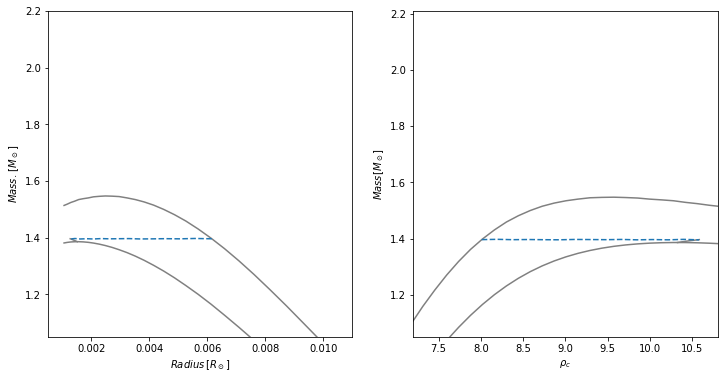

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(Rstawd_kep*Rdim/Rsun, Mdim*Mstawd_kep, color="gray")
ax1.plot(Rrotwd_kep*Rdim/Rsun, Mdim*Mrotwd_kep, color="gray")
ax1.plot(Rrotwd_seq*Rdim/Rsun, Mdim*Mrotwd_seq, color="gray")

ax1.plot(Rrotwd_eq*Rdim/Rsun, Mrotwd*Mdim, ls="--" ) 

ax1.set_xlabel("$Radius \, [R_\odot]$")
ax1.set_ylabel("$Mass. \, [M_\odot]$")

ax1.set_ylim(1.05,2.2)
ax1.set_xlim(0.0005,0.011)

ax2.plot(rhowd_kep, Mdim*Mstawd_kep, color="gray")
ax2.plot(rhowd_kep, Mdim*Mrotwd_kep, color="gray")
ax2.plot(rhowd_seq, Mdim*Mrotwd_seq, color="gray")


ax2.plot(rhowd, Mrotwd*Mdim, ls="--") 

ax2.set_xlabel("$\\rho_c$")
ax2.set_ylabel("$Mass [M_\\odot]$")

ax2.set_ylim(1.05,2.21)
ax2.set_xlim(7.2,10.8)

plt.show()

In [75]:
# Interpolation relations to stablish the initial conditions

Kep_Omega = interp1d( Mrotwd_kep*Mdim , Omegawd_kep )
Kep_Req   = interp1d( Mrotwd_kep*Mdim ,  Rrotwd_kep )
Kep_J     = interp1d( Mrotwd_kep*Mdim ,  Jwd_kep )
Kep_rho   = interp1d( Mrotwd_kep*Mdim ,  rhowd_kep )

Stt_rho   = interp1d( Mstawd_kep*Mdim, rhowd_kep  )

Masswd0   = 1.39
Omegawd_0 = Kep_Omega(Masswd0)
Reqwd_0   = Kep_Req(Masswd0)
jwd_0     = Kep_J(Masswd0)
rhowd_0   = Kep_rho(Masswd0)

print("The star stars at the keplerian sequence with Mass0 = ", Masswd0, " Msun \tOmega0 = ", Omegawd_0*Rdim/c, " \t Req0 = ", Reqwd_0*Rdim/Rsun)

The star stars at the keplerian sequence with Mass0 =  1.39  Msun 	Omega0 =  1298.8583334285597  	 Req0 =  0.006230065125694928


The evolution of the star's angular momentum and the evoluation of the star central density is:

$$\frac{d J}{dt} = − T_{dipole}  $$
$$ \frac{dT}{dt} =  \frac{1}{c_v}\frac{dL}{dm}+\frac{\epsilon_\nu-\epsilon_c}{c_v} + \frac{P}{c_v\rho}\frac{d ln\rho}{dJ}\dot{J} $$
$$L=-\frac{16}{3} \frac{4\pi r^2\sigma_BT^3}{\kappa\rho}\frac{dT}{dr}$$
The spin evolves due to the electromagnetic energy losees:
$$T_{dipole}= \frac{\mu_{WD}^2 \Omega^3}{c^3}(1+\sin^2(\theta)) $$

with $\mu_{WD}= B R^3$

In [134]:
Req_j       = interp1d( Jwd / JJdim , Reqwd / Reqwd_0 , kind='linear', bounds_error=False )    # Radius as function of angular momentum
Omega_j     = interp1d( Jwd / JJdim , Omegawd / Omegawd_0, kind='linear', bounds_error=False ) # Angular velocity as function of angular momentum
rho_j       = interp1d( Jwd / JJdim , rhowd , kind='linear', bounds_error=False )              # central density as function of angular momentum
DrhoDj_dats = fit_derivative( Jwd / JJdim , rhowd )
Drho_dj     = interp1d( Jwd / JJdim , DrhoDj_dats ,kind='linear', bounds_error=False ) # Derivative of density

def cv_gas(A,Z,rho,T):
    
    tr    = kappaB * T / ( me * c2 )

    Cve   = EOS.Cvienm(A,Z,rho,tr)
    Cvion = EOS.cv_ion()    
    
    return Cve + Cvion

def muWD(Bs,Rwd):
    #magnetic moment WD
    return Bs * Rwd**3.0 

def TdipIII(R_wd,Omega_wd):
    return ( R_wd**6.0 ) * ( Omega_wd**3.0 )

def AdipIII(tau, Omegawd_0, Rwd_0, Jwd_0,Bs):
    
    mu_wd = muWD(Bs,Rwd_0)
    
    return (1.0/ (3.0*c**3)) * (1.0 + np.sin(0.5*np.pi)**2) * ( Omegawd_0 ) **3.0 * mu_wd**2 * tau  / Jwd_0

def Torque_dip(t,y,ffx):
    #Equations to integrate
    jwd    = y[0]
    
    AAdip  = ffx[0]
    cc     = ffx[1]
    #tau   = ffx[2]
   
    Reqx   = Req_j( jwd )
    Omegax = Omega_j( jwd )
    
    if cc==0:
        # magnetic field constant
        ec1 = -np.log(10.0) * np.power(10.0,t) * AAdip * TdipIII(Reqx,Omegax)
    else:
        # magnetic flux conserved
        BB = 1.0 / Reqx
        ec1 = -np.log(10.0) * np.power(10.0,t) * AAdip * TdipIII(Reqx,Omegax) * BB**4
        
    return np.array( [ ec1 ] )

def RungheKut(t,y,h,fx):
    dsy1 = Torque_dip(t,y,fx)
    #print dsy1
    dsy2 = Torque_dip( t+h/2.0 , y + dsy1[0] * h / 2.0 , fx )
    #print dsy2
    dsy3 = Torque_dip( t + h / 2.0 , y + dsy2[0] * h / 2.0 , fx )
    #print dsy3
    dsy4 = Torque_dip( t + h  , y + dsy3[0] * h , fx )
    #print dsy4
    jnew = y[0] + (1.0/6.0) * h * ( dsy1[0] + 2.0 * ( dsy2[0] + dsy3[0] ) + dsy4[0] )
    
    return [ jnew ]



In [146]:
def TT_profile(x, Ts, Tc):
    """Initial radial temperature profile """
    
    return Ts + (Tc - Ts) * x ** 2

dr  = 1e-6
rf  = 1.0
NN  = 100 

rhoc  = np.power(10, rhowd_0)/Sigma02 
pc    = EoS_RFMT(np.power(10, rhowd_0)/Sigma02)
dedpc = np.power(10, DeDpF( np.log10( pc ) ))

y0i   = WD.IntCond_Static(rhoc, pc , dr )
MS    = WD.StaticSeq( y0i , dr, rf, EOSs )
dr    = MS[1] / NN
y0i   = WD.IntCond_Rotating( jwd_0, MS[3],  rhoc , pc, MS[2], dr , rf , EOSs, dedpc  )   
MR    = WD.MassRadius_Structure(y0i, dr, rf,  EOSs, DeDp_2)

Ts       = ( 1e-2*Lsun/(4*np.pi*(Reqwd_0*Rdim)**2*SigmaSB) )**(1/4)

Jstar     = MR[-1][0]**4 * MR[-1][4] / 6.0
J2        = Jstar*Jstar
DeltaM    = MR[-1][6] + Jstar*Jstar / MR[-1][0]**3 

grid_x   = np.linspace(0.05, 1.0, NN)

func_mass = interp1d( [ MR[i][0]/MR[-1][0] for i in range(len(MR)) ]  , [ MR[i][1] for i in range(len(MR)) ], kind='linear', bounds_error=False )
func_rho = interp1d( [ MR[i][0]/MR[-1][0] for i in range(len(MR)) ]  ,  [  EoS_RFMT_02(MR[i][2]) for i in range(len(MR)) ] , kind='linear', bounds_error=False ) 

grid_r   = grid_x*MR[-1][0]
grid_m   = func_mass( grid_x) 
grid_rho = func_rho( grid_x) 
grid_T   = np.array( [ TT_profile( grid_m[i]/grid_m[-1], 1e7, Ts) / Tdim for i in range(len(grid_x)) ] )


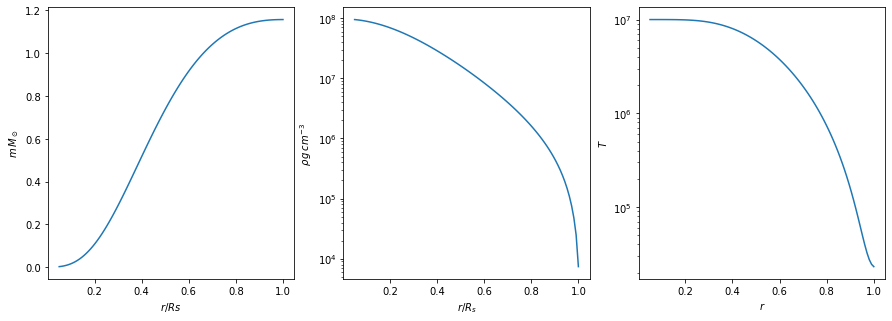

In [147]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(131)

plt.plot( grid_x , grid_m*Mdim)
plt.xlabel("$r /Rs$")
plt.ylabel("$m \, M_\\odot$")

plt.subplot(132)

plt.semilogy( grid_x , grid_rho*Sigma02)
plt.xlabel("$r/R_s$")
plt.ylabel("$\\rho\, g \, cm^{-3}$")

plt.subplot(133)
plt.semilogy( grid_r/grid_r[-1] , Tdim*grid_T)
plt.xlabel("$r$")
plt.ylabel("$T$")

plt.show()

In [148]:
Bs0     = 1e6
jwd_dim = jwd_0 * JJdim * Rdim**2 / Jdim
tauD    = 1.0 / AdipIII(1.0, Omegawd_0*c / Rdim, Reqwd_0 * Rdim, jwd_dim , Bs0)
A0      = AdipIII(tauD,  Omegawd_0*c/Rdim, Reqwd_0 * Rdim, Jadim , Bs0) 

i = 0; 
dt = 5e-1
t0 = -3
yy0 = [ [ t0, Jwd[0]/JJdim ] ]


while rho_j( yy0[i][1] ) < rhobeta and yy0[i][1] > 1.01*Jwd[-1] / JJdim:
    yynew = RungheKut( t0 + i*dt, [yy0[i][1]], dt, [A0,0])
    
    print(yynew)   
    i+=1
    yy0.append( [t0+i*dt,yynew[0]] )

    dtt =np.power(10, t0+i*dt )*np.log(10)*dt

    Nr = len( grid_r )
    grid_dT = np.zeros(Nr)
    grid_dL = np.zeros(Nr)
    kappa   = np.zeros(Nr)
    cv_g    = np.zeros(Nr)
    energy  = np.zeros(Nr) 

    for j in range(0,Nr):
       
        kappa[j]  = ( 1.0 / op.opacity( 12, 6, grid_rho[j]*Sigma02, Tdim*grid_T[j]) ) * ( c2 / G ) / Rdim
        cv_g[j]   = (kappaB * Tdim * Sigma02 / ( 12 * mu ) ) * cv_gas(12,6, grid_rho[j]*Sigma02, Tdim*grid_T[j])
        energy[j] = eCC.QCC( grid_rho[j]*Sigma02 , Tdim*grid_T[j],6,12,1.0) - nunu.QnuTotal( grid_rho[j]*Sigma02,Tdim*grid_T[j], 12, 6) 
    
        if j ==0:
            grid_dT[j] = ( grid_T[j+1] - grid_T[j] ) / ( grid_r[j+1] - grid_r[j] )
        elif j == Nr-1:
            grid_dT[j] = ( grid_T[j] - grid_T[j-1] ) / ( grid_r[j] - grid_r[j-1] )
        else:
            grid_dT[j] = ( grid_T[j+1] - grid_T[j-1] ) / ( grid_r[j+1]- grid_r[j-1] )
            
    grid_L = -16 * ( grid_r**2 * grid_T**3 * grid_dT) / ( 3.0 * kappa[j] * grid_rho[j] ) 
        
    for j in range(0,Nr):
        if j ==0:
            grid_dL[j] = ( grid_L[j+1] - grid_L[j] ) / ( grid_m[j+1] - grid_m[j] )
        elif j == Nr-1:
            grid_dL[j] = ( grid_L[j] - grid_L[j-1] ) / ( grid_m[j] - grid_m[j-1] )
        else:
            grid_dL[j] = ( grid_L[j+1] - grid_L[j-1] ) / ( grid_m[j+1]- grid_m[j-1] )
                
    grid_T = grid_T + ( ( G / c2 ) *( Ldim*Sigma02 / Rdim) * grid_dL *grid_rho  + energy ) * dtt / ( cv_g * grid_rho)

    logrhowdx = rho_j( yynew[0] ) 
    rhowdc    = np.power(10.0, logrhowdx)/Sigma02
    pc        = EoS_RFMT(rhowdc)
    dedpc     = np.power(10, DeDpF( np.log10( pc ) ))
    y0i       = WD.IntCond_Static(rhowdc, pc, dr )
    MS    = WD.StaticSeq( y0i , dr, rf, EOSs )
    dr    = MS[1]/NN
    y0i   = WD.IntCond_Rotating( yynew[0]*JJdim , MS[3],  rhowdc  , pc , MS[2], dr , rf , EOSs, dedpc  )   
    MR    = WD.MassRadius_Structure(y0i, dr, rf,  EOSs, DeDp_2)

    func_mass = interp1d( [ MR[i][0]/MR[-1][0] for i in range(len(MR)) ]  , [ MR[i][1] for i in range(len(MR)) ], kind='linear', bounds_error=False )
    func_rho = interp1d( [ MR[i][0]/MR[-1][0] for i in range(len(MR)) ]  ,  [  EoS_RFMT_02(MR[i][2]) for i in range(len(MR)) ] , kind='linear', bounds_error=False ) 

    grid_r   = grid_x*MR[-1][0]
    grid_m   = func_mass( grid_x) 
    grid_rho = func_rho( grid_x) 

    #grid_r   = np.array( [ MR[i][0] for i in range(len(MR)) ] )
    #grid_m   = np.array( [ MR[i][1] for i in range(len(MR)) ] )
    #grid_rho = np.array( [  EoS_RFMT_02(MR[i][2]) for i in range(len(MR)) ]  )



[np.float64(0.8862282195147697)]
[np.float64(0.8862282195147679)]
[np.float64(0.8862282195147625)]
[np.float64(0.8862282195147452)]
[np.float64(0.8862282195146903)]
[np.float64(0.8862282195145168)]
[np.float64(0.886228219513968)]
[np.float64(0.8862282195122327)]
[np.float64(0.8862282195067452)]
[np.float64(0.8862282194893923)]
[np.float64(0.8862282194345175)]
[np.float64(0.8862282192609879)]
[np.float64(0.8862282187122394)]
[np.float64(0.8862282169769445)]
[np.float64(0.8862282114894602)]
[np.float64(0.8862281941365115)]
[np.float64(0.8862281392616764)]
[np.float64(0.886227965732278)]
[np.float64(0.8862274169848041)]
[np.float64(0.8862256816995882)]
[np.float64(0.8862201943125326)]
[np.float64(0.8862028423371787)]
[np.float64(0.8861479772337625)]
[np.float64(0.8859745451224105)]
[np.float64(0.8854267695875261)]
[np.float64(0.8837011743817397)]
[np.float64(0.8783097673037404)]
[np.float64(0.861889376472336)]


ValueError: The function value at x=-10.0 is NaN; solver cannot continue.

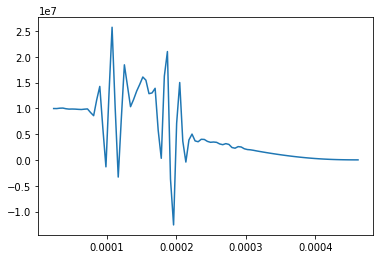

In [149]:
plt.plot(grid_r, grid_T*Tdim)

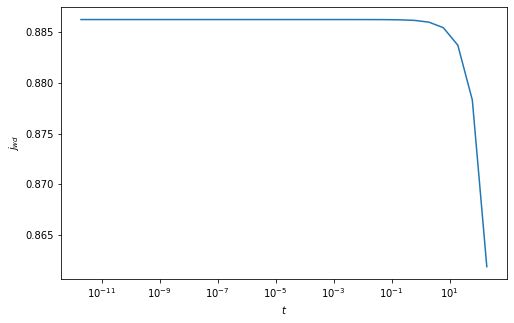

In [150]:
fig = plt.figure(figsize=(8,5))

plt.semilogx( np.power(10,np.array(yy0)[:,0]) * tauD / ( 1e6 * yr ), np.array(yy0)[:,1] )

plt.ylabel("$j_{wd}$")
plt.xlabel("$t$")

#plt.xlim(5e-3, 1e7)

plt.show()

In [151]:
#---cabon-ignition line--------
def tauCC(rhox,Txi,Abar,Zbar,XC):
    T = np.power(10.0,Txi)
    rho = np.power(10.0, rhox)
    return np.log10( nunu.QnuTotal(rho,T,Abar,Zbar) / eCC.QCC(rho,T,Zbar,Abar,XC) )

def funcCC(T,rhox):
  #  T = np.power(10.0,Txi)
    rho = np.power( 10.0 , rhox )
    return eCC.QCC(rho,T,6.0,12.0,0.5)


############ Ignition line------------
Tx = np.linspace( 7.0, 9.0, 50)
NN = len(Tx)
rhoCC = np.zeros(NN)

i=0
for xx in Tx:
    Tc = brentq(tauCC , 2.0 , 10.0 ,args=(xx,12.0,6.0,0.5))
    rhoCC[i] = Tc
    i+=1


/tmp/ipykernel_10142/2028006887.py:5: RuntimeWarning: invalid value encountered in log10
  plt.plot(np.log10(grid_rho*Sigma02), np.log10(grid_T*Tdim))


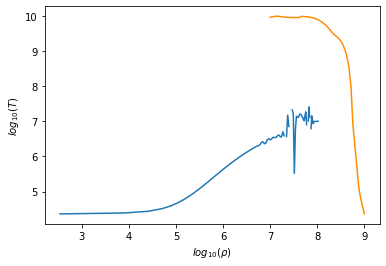

In [154]:
fig= plt.figure()

plt.plot(Tx,rhoCC, color="DarkOrange" )

plt.plot(np.log10(grid_rho*Sigma02), np.log10(grid_T*Tdim))

plt.xlabel("$log_{10}(\\rho)$")
plt.ylabel("$log_{10}(T)$")

#plt.ylim(7,10.5)


plt.show()